In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from numba import jit


# Isining #

Temperatur: 4
Temperatur: 3.8
Temperatur: 3.61
Temperatur: 3.4294999999999995
Temperatur: 3.2580249999999995
Temperatur: 3.0951237499999995
Temperatur: 2.940367562499999
Temperatur: 2.793349184374999
Temperatur: 2.653681725156249
Temperatur: 2.5209976388984363
Temperatur: 2.3949477569535143
Temperatur: 2.2752003691058382
Temperatur: 2.161440350650546
Temperatur: 2.053368333118019
Temperatur: 1.9506999164621177
Temperatur: 1.8531649206390117
Temperatur: 1.760506674607061
Temperatur: 1.6724813408767079
Temperatur: 1.5888572738328723
Temperatur: 1.5094144101412286
Temperatur: 1.433943689634167
Temperatur: 1.3622465051524586
Temperatur: 1.2941341798948356
Temperatur: 1.2294274709000939
Temperatur: 1.167956097355089
Temperatur: 1.1095582924873346
Temperatur: 1.054080377862968
Temperatur: 1.0013763589698195


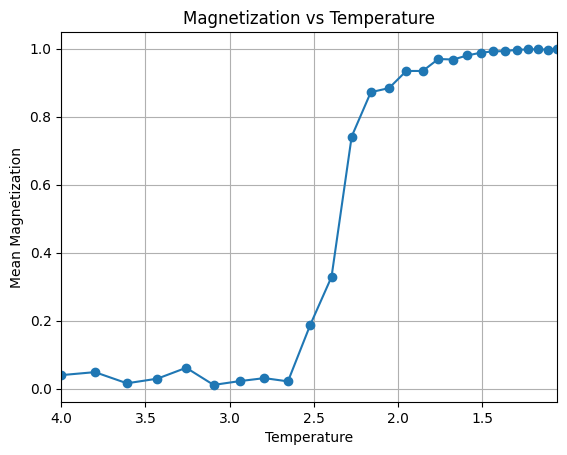

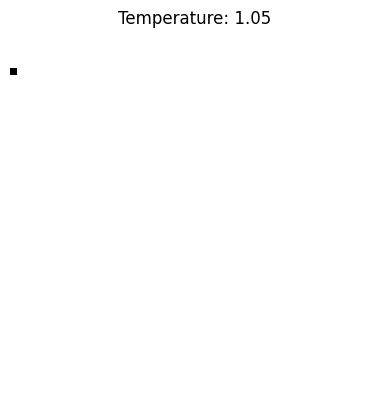

In [4]:

NX = 50                         # Grid width
NY = 50                         # Grid height
J = 1                           # Interaction strength
N_PER_TEMP = 40 * NX * NY       # Monte Carlo steps per temperature
TEMP_START = 4                  # Starting temperature
TEMP_END = 0.1                  # Ending temperature
TEMP_FACTOR = 0.95              # Temperature reduction factor

spins = np.random.choice([-1, 1], size=(NX, NY))

@jit(nopython=True)
def metropolis_step(spins, T):
    """Perform a single Metropolis update by picking a random spin and deciding whether to flip it."""
    beta = 1 / T 

    
    for _ in range(NX * NY):  
        i, j = np.random.randint(0, NX), np.random.randint(0, NY) 

        neighbor_sum = (
            spins[(i + 1) % NX, j] + spins[(i - 1) % NX, j] +
            spins[i, (j + 1) % NY] + spins[i, (j - 1) % NY]
        )
        dE = 2 * J * spins[i, j] * neighbor_sum
        
        if dE < 0 or np.random.rand() < np.exp(-beta * dE):
            spins[i, j] *= -1

T = TEMP_START
magnetizations = []
temperatures = []
frames = []

while T > TEMP_END:
    print(f"Temperatur: {T}")
    for _ in range(N_PER_TEMP):
        metropolis_step(spins, T)
    
    magnetization = np.abs(np.sum(spins)) / (NX * NY) 
    if magnetization == 1:
        break
    magnetizations.append(magnetization)
    temperatures.append(T)
    frames.append(spins.copy()) 
    
    T *= TEMP_FACTOR 

plt.figure()
plt.plot(temperatures, magnetizations, marker='o')
plt.xlabel("Temperature")
plt.ylabel("Mean Magnetization")
plt.title("Magnetization vs Temperature")
plt.xlim(max(temperatures), min(temperatures))
plt.grid()
plt.show()

fig, ax = plt.subplots()
def update(frame):
    ax.clear()
    ax.imshow(frames[frame], cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f"Temperature: {temperatures[frame]:.2f}")
    ax.axis('off')

ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=200)
ani.save("ising_model_evolution.mp4", writer="ffmpeg")
plt.show()

